In [1]:
!nvidia-smi

Tue May  5 16:30:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:18:00.0 Off |                    0 |
| N/A   15C    P0             67W /  700W |       1MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/ocean/projects/asc170022p/mtragoza/lung-project/notebooks/emory-4dct'

In [3]:
import sys, os
sys.path.append(os.environ['LP'])
import project
from project.core.utils import pprint

# Metadata assignment

In [4]:
import pandas as pd

metadata = pd.DataFrame({
    'case_id': ['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10'],
    'case_num': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'case_dir': ['Case1Pack', 'Case2Pack', 'Case3Pack', 'Case4Pack', 'Case5Pack', 'Case6Pack', 'Case7Pack', 'Case8Deploy', 'Case9Pack', 'Case10Pack'],
    'img_suffix': ['_s', '-ssm', '-ssm', '-ssm', '-ssm', '', '', '', '', ''],
    'shape_x': [256, 256, 256, 256, 256, 512, 512, 512, 512, 512],
    'shape_y': [256, 256, 256, 256, 256, 512, 512, 512, 512, 512],
    'shape_z': [ 94, 112, 104,  99, 106, 128, 136, 128, 128, 120],
    'spacing_x': [0.97, 1.16, 1.15, 1.13, 1.10, 0.97, 0.97, 0.97, 0.97, 0.97],
    'spacing_y': [0.97, 1.16, 1.15, 1.13, 1.10, 0.97, 0.97, 0.97, 0.97, 0.97],
    'spacing_z': [2.50, 2.50, 2.50, 2.50, 2.50, 2.50, 2.50, 2.50, 2.50, 2.50],
    'n_features': [1280, 1487, 1561, 1166, 1268, 419, 398, 476, 342, 435],
})
#metadata.to_csv('../../data/Emory-4DCT/metadata.csv', index=False)
metadata

,case_id,case_num,case_dir,img_suffix,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z,n_features
0,case1,1,Case1Pack,_s,256,256,94,0.97,0.97,2.5,1280
1,case2,2,Case2Pack,-ssm,256,256,112,1.16,1.16,2.5,1487
2,case3,3,Case3Pack,-ssm,256,256,104,1.15,1.15,2.5,1561
3,case4,4,Case4Pack,-ssm,256,256,99,1.13,1.13,2.5,1166
4,case5,5,Case5Pack,-ssm,256,256,106,1.10,1.10,2.5,1268
5,case6,6,Case6Pack,,512,512,128,0.97,0.97,2.5,419
6,case7,7,Case7Pack,,512,512,136,0.97,0.97,2.5,398
7,case8,8,Case8Deploy,,512,512,128,0.97,0.97,2.5,476
8,case9,9,Case9Pack,,512,512,128,0.97,0.97,2.5,342
9,case10,10,Case10Pack,,512,512,120,0.97,0.97,2.5,435


In [5]:
phases = pd.DataFrame({
    'phase_name': ['T00', 'T10', 'T20', 'T30', 'T40', 'T50', 'T60', 'T70', 'T80', 'T90'],
    'phase_percent': [0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
    'image': [True, True, True, True, True, True, True, True, True, True],
    'sampled_feats': [True, True, True, True, True, True, False, False, False, False],
    'extreme_feats': [True, False, False, False, False, True, False, False, False, False,],
})
#phases.to_csv('../../data/Emory-4DCT/phases.csv', index=False)
phases

,phase_name,phase_percent,image,sampled_feats,extreme_feats
0,T00,0,True,True,True
1,T10,10,True,True,False
2,T20,20,True,True,False
3,T30,30,True,True,False
4,T40,40,True,True,False
5,T50,50,True,True,True
6,T60,60,True,False,False
7,T70,70,True,False,False
8,T80,80,True,False,False
9,T90,90,True,False,False


# Path validation

In [14]:
%ls ../../data/Emory-4DCT

downloads/  extracted/  metadata/  processed/


In [15]:
data_config = {
    'name': 'Emory-4DCT',
    'root': '../../data/Emory-4DCT',
    'examples': {
        'variant': 'TEST',
        'state_pairs': [('T50', 'T00')]
    }
}
project.core.utils.pprint(data_config, 4)

dict(len=3)
├── 'name':     'Emory-4DCT'
├── 'root':     '../../data/Emory-4DCT'
└── 'examples': dict(len=2)
    ├── 'variant':     'TEST'
    └── 'state_pairs': list(len=1)
        └── 0: tuple(len=2)
            ├── 0: 'T50'
            └── 1: 'T00'


In [16]:
%autoreload
import project.datasets
dataset_cls = project.datasets.Dataset.get_subclass(data_config['name'])
ds = dataset_cls(data_config['root'])
ds

In [17]:
# validate paths
for sid in ds.subjects():
    for state in ds.image_states():
        p = ds.source_path(sid, state, asset_type='image')
        assert p.is_file(), p
    for state in ds.sampled_states():
        p = ds.source_path(sid, state, asset_type='sampled_feats')
        assert p.is_file(), p
    for state in ds.extreme_states():
        p = ds.source_path(sid, state, asset_type='extreme_feats')
        assert p.is_file(), p
True

True

In [18]:
examples = ds.list_examples(
    selectors=data_config.get('selectors', {}),
    **data_config.get('examples', {})
)
len(examples)

10

In [19]:
%autoreload
ex = examples[0]
pprint(ex, 3, 20)

Example()
├── dataset:  'Emory-4DCT'
├── subject:  'case1'
├── variant:  'TEST'
├── paths:    dict(len=15)
|   ├── 'ref_source':    PosixPath('../../data/Emory-4DCT/extracted/Case1Pack/Images/case1_T00_s.img')
|   ├── 'init_source':   PosixPath('../../data/Emory-4DCT/extracted/Case1Pack/Images/case1_T50_s.img')
|   ├── 'curr_source':   PosixPath('../../data/Emory-4DCT/extracted/Case1Pack/Images/case1_T00_s.img')
|   ├── 'ref_nifti':     PosixPath('../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00.nii.gz')
|   ├── 'init_nifti':    PosixPath('../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50.nii.gz')
|   ├── 'curr_nifti':    PosixPath('../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00.nii.gz')
|   ├── 'init_resample': PosixPath('../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50_std.nii.gz')
|   ├── 'curr_resample': PosixPath('../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00_std.nii.gz')
|   ├── 'segment_dir':   PosixPath('../../data/Emor

# Preprocessing tests

In [20]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 2.5),
        'interpolation': 'linear',
        'default_value': -1024.
    },
    'image_segmentation': {
        'tasks': [
            {
                'task_name': 'total',
                'roi_subset': [
                    'lung_upper_lobe_right',
                    'lung_middle_lobe_right',
                    'lung_lower_lobe_right',
                    'lung_upper_lobe_left',
                    'lung_lower_lobe_left',
                ],
            },
            {
                'task_name': 'lung_vessels'
            },
            {
                'task_name': 'body'
            }
        ],
        'combine': True
    },
    'region_labeling': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
            'lung_airways',
            'lung_airways_wall',
            'lung_arteries',
            'lung_veins',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {}
}

In [21]:
%autoreload
import project.preprocessing.api as api

api.preprocess_example(ex, proc_config)

INFO: ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00.nii.gz exists; Skipping stage convert_image_to_nifti
INFO: ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50.nii.gz exists; Skipping stage convert_image_to_nifti
INFO: ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00.nii.gz exists; Skipping stage convert_image_to_nifti
INFO: ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: ../../data/Emory-4DCT/processed/TEST/case1/masks/case1_T50_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: ../../data/Emory-4DCT/processed/TEST/case1/masks/case1_T50_std_tseg_regions.nii.gz exists; Skipping stage create_multi_region_map
INFO: ../../data/Emory-4DCT/processed/TEST/case1/fields/case1_T50_std_tseg_corr_T00.nii.gz exists; Skipping stage register

In [23]:
import numpy as np

img0_path = ex.paths['init_resample']
img1_path = ex.paths['curr_resample']

mask_path = ex.paths['region_map']
disp_path = ex.paths['disp_field']
mesh_path = ex.paths['interp_mesh']

affine = project.core.fileio.load_nibabel(img0_path).affine
print(affine)

spacing = tuple(float(d) for d in affine[:3,:3] @ np.ones(3))
print(spacing)

img0 = project.core.fileio.load_nibabel(img0_path).get_fdata()
img1 = project.core.fileio.load_nibabel(img1_path).get_fdata()
mask = project.core.fileio.load_nibabel(mask_path).get_fdata()
disp = project.core.fileio.load_nibabel(disp_path).get_fdata()

Loading ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50_std.nii.gz
[[-1.          0.         -0.         -0.17500365]
 [ 0.         -1.         -0.         -0.17500365]
 [ 0.          0.         -2.5         0.        ]
 [ 0.          0.          0.          1.        ]]
(-1.0, -1.0, -2.5)
Loading ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50_std.nii.gz
Loading ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T00_std.nii.gz
Loading ../../data/Emory-4DCT/processed/TEST/case1/masks/case1_T50_std_tseg_regions.nii.gz
Loading ../../data/Emory-4DCT/processed/TEST/case1/fields/case1_T50_std_tseg_corr_T00.nii.gz


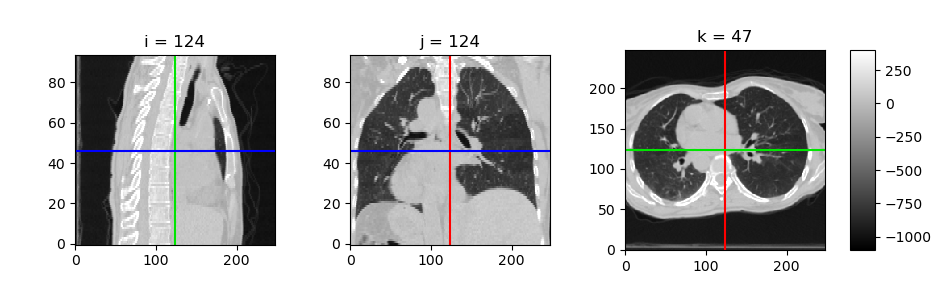

In [25]:
import project.visual.matplotlib as mpl_viz
import matplotlib.pyplot as plt
plt.close('all')

mpl_viz.SliceViewer(img0, vox_spacing=spacing, cmap='gray', vmin=-1100, vmax=400)

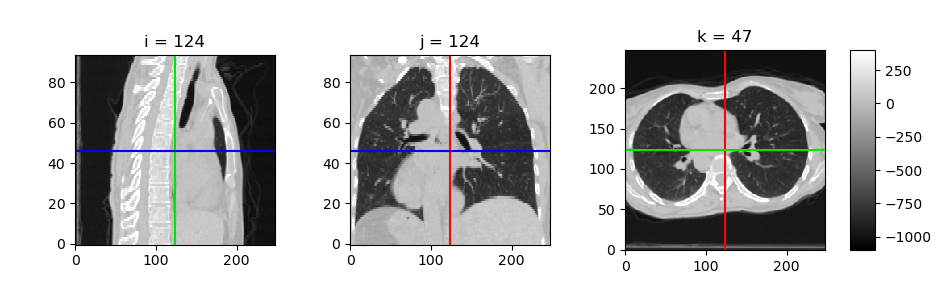

In [26]:
mpl_viz.SliceViewer(img1, vox_spacing=spacing, cmap='gray', vmin=-1100, vmax=400)

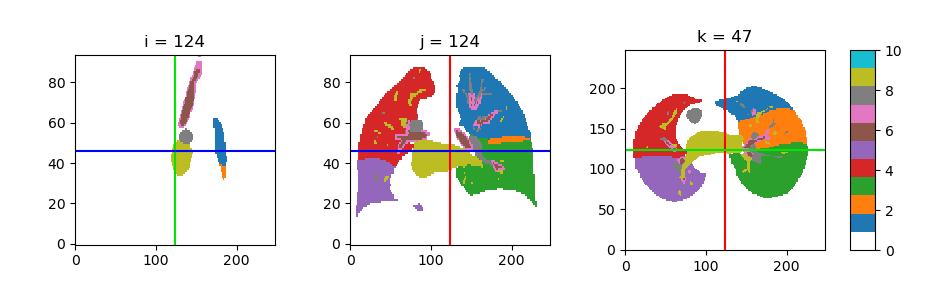

In [27]:
cmap = mpl_viz.get_label_cmap(n_labels=10, select=None, include_background=True)

mpl_viz.SliceViewer(mask, vox_spacing=spacing, cmap=cmap, vmin=0, vmax=10)

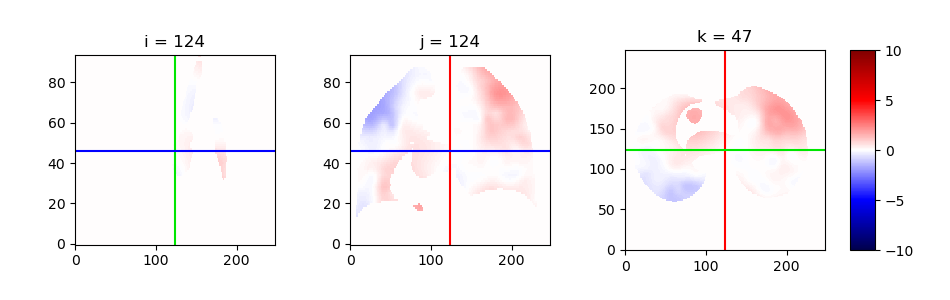

In [28]:
mpl_viz.SliceViewer(disp[...,0] * (mask > 0), vox_spacing=spacing, cmap='seismic', vmin=-10, vmax=10)

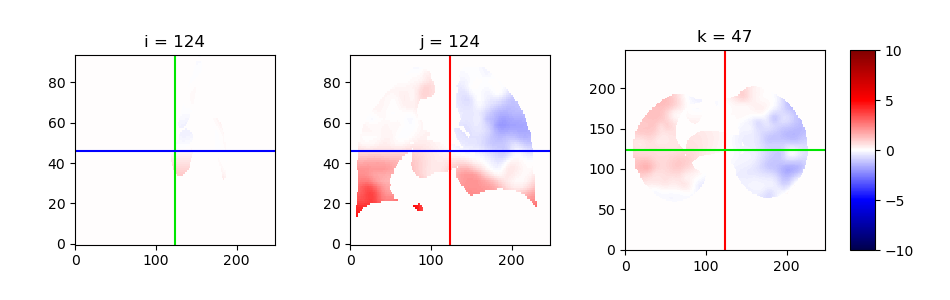

In [29]:
mpl_viz.SliceViewer(disp[...,1] * (mask > 0), vox_spacing=spacing, cmap='seismic', vmin=-10, vmax=10)

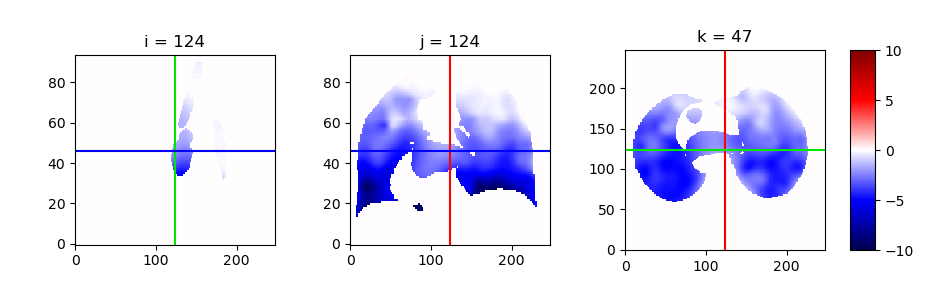

In [30]:
mpl_viz.SliceViewer(disp[...,2] * (mask > 0), vox_spacing=spacing, cmap='seismic', vmin=-10, vmax=10)

In [31]:
def compute_jacobian(disp, spacing):
    u = disp[...,0]
    v = disp[...,1]
    w = disp[...,2]

    du_dx, du_dy, du_dz = np.gradient(u, *spacing, edge_order=2)
    dv_dx, dv_dy, dv_dz = np.gradient(v, *spacing, edge_order=2)
    dw_dx, dw_dy, dw_dz = np.gradient(w, *spacing, edge_order=2)

    J = np.empty(disp.shape[:-1] + (3,3), dtype=disp.dtype)

    J[..., 0, 0] = du_dx + 1
    J[..., 0, 1] = du_dy
    J[..., 0, 2] = du_dz

    J[..., 1, 0] = dv_dx
    J[..., 1, 1] = dv_dy + 1
    J[..., 1, 2] = dv_dz

    J[..., 2, 0] = dw_dx
    J[..., 2, 1] = dw_dy
    J[..., 2, 2] = dw_dz + 1

    return J

J = compute_jacobian(disp, spacing)
det_J = np.linalg.det(J)

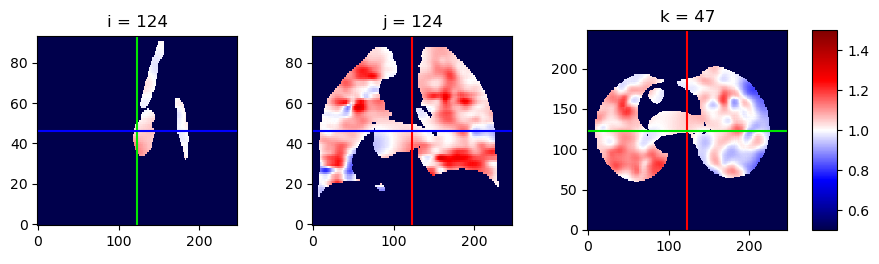

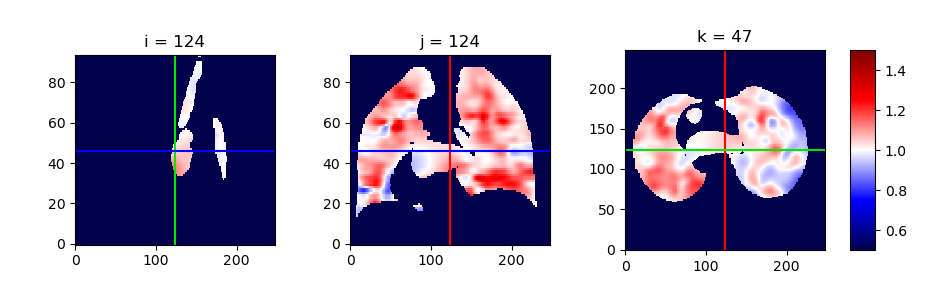

In [32]:
mpl_viz.SliceViewer(det_J * (mask > 0), vox_spacing=spacing, cmap='seismic', vmin=0.5, vmax=1.5).fig

In [33]:
nx, ny, nz = img0.shape[:3]
dx, dy, dz = spacing
z_slice = int((nz - 1) * 0.45)
z_aspect = dy / dx

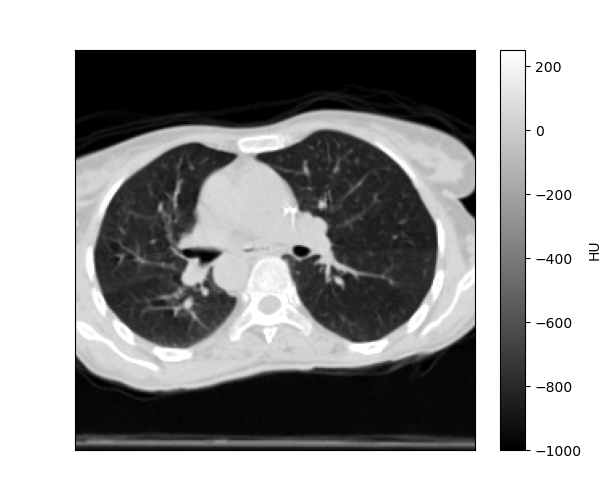

In [35]:
fig, axes, cax = mpl_viz.subplot_grid(1, 1, ax_height=4, ax_width=4, padding=(0.75,0.75,0.5,0.5), cbar_width=0.25, cbar_spacing=0.25)

im = axes[0,0].imshow(img0[::-1,::-1,z_slice].T, origin='lower', aspect=z_aspect, cmap='gray', vmin=-1000, vmax=250)
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])
plt.colorbar(im, cax=cax, label='HU')

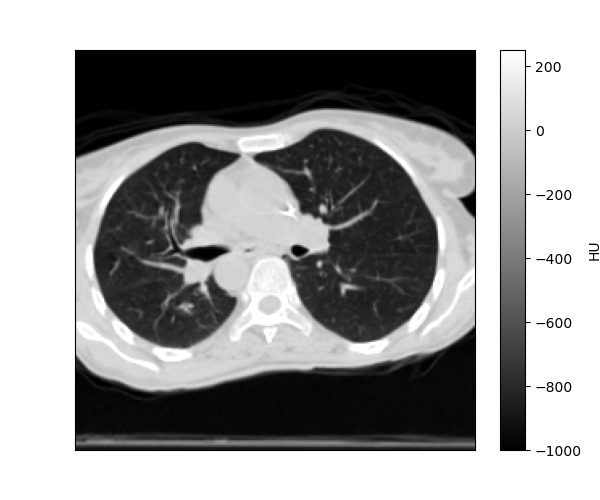

In [36]:
fig, axes, cax = mpl_viz.subplot_grid(1, 1, ax_height=4, ax_width=4, padding=(0.75,0.75,0.5,0.5), cbar_width=0.25, cbar_spacing=0.25)

im = axes[0,0].imshow(img1[::-1,::-1,z_slice].T, origin='lower', aspect=z_aspect, cmap='gray', vmin=-1000, vmax=250)
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])
plt.colorbar(im, cax=cax, label='HU')

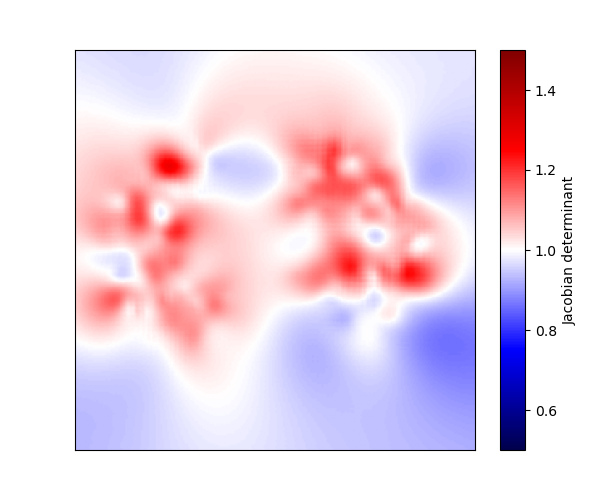

In [37]:
fig, axes, cax = mpl_viz.subplot_grid(1, 1, ax_height=4, ax_width=4, padding=(0.75,0.75,0.5,0.5), cbar_width=0.25, cbar_spacing=0.25)

im = axes[0,0].imshow(det_J[::-1,::-1,z_slice].T, origin='lower', aspect=z_aspect, cmap='seismic', vmin=0.5, vmax=1.5)
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])
plt.colorbar(im, cax=cax, label='Jacobian determinant')

In [38]:
mesh = project.core.fileio.load_meshio(ex.paths['interp_mesh'])
mesh

Loading ../../data/Emory-4DCT/processed/TEST/case1/meshes/case1_T50_std_tseg_regions_pyg_int.xdmf


<meshio mesh object>
  Number of points: 43782
  Number of cells:
    tetra: 227448
  Point data: medit:ref, image, u_true
  Cell data: medit:ref, region, image, u_true

In [39]:
mesh.cell_data['image'][0].shape

(227448,)

In [48]:
import project.visual.pyvista as pv_viz

pv_viz.plot_mesh(mesh, scalars='u_true', cmap='seismic', vmin=-1, vmax=1).show(jupyter_backend='trame')

2026-05-05 14:31:34.290 ( 553.549s) [    14F9D7C58400]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


TypeError: "vmin", "vmax" are invalid keyword arguments for `_common_arg_parser`

# Baseline estimation

In [48]:
opt_config = {
    'targets': ['E'],
    'param_specs': {
        'E': {'mode': 'log10', 'mean': 3.4863, 'std': 0.3271},
        'nu': {'mode': 'logit', 'min': 0.0001, 'max': 0.4999},
        'rho': {'mode': 'log10', 'mean': 3.0, 'std': 0.1}
    },
    'physics_adapter': {
        'default_nu': 0.4,
        'default_rho': 1000,
        'scalar_degree': 1,
        'vector_degree': 1
    },
    'pde_solver': {
        '_class': 'WarpFEMSolver',
        'relative_loss': True,
        'tv_reg_weight': 0.001
    },
    'optimizer': {
        '_class': 'LBFGS',
        'lr': 1.0,
        'max_iter': 100,
        'history_size': 10,
        'line_search_fn': 'strong_wolfe',
        'global_steps': 10,
        'local_steps': 10
    }
}

In [49]:
import warp
warp.init()
warp.get_devices()

['cpu', 'cuda:0']

In [50]:
%autoreload
import project.optimization

outputs = project.api.RunOutputs(stage='optimize')
output_path = outputs.mesh_path(ex, name='optimized')
raster_base = outputs.raster_base(ex)

project.optimization.optimize_example(ex, opt_config, output_path, raster_base)

Loading ../../data/Emory-4DCT/processed/TEST/case1/images/case1_T50_std.nii.gz
Loading ../../data/Emory-4DCT/processed/TEST/case1/meshes/case1_T50_std_tseg_regions_pyg_int.xdmf
Loading ../../data/Emory-4DCT/processed/TEST/case1/masks/case1_T50_std_tseg_regions.nii.gz
Targets: ['E']
Stage 1: Global optimization
iter	loss (rel_delta)	grad_norm (rel_init)	param_norm (update_norm)
0	2.9527e-02 (nan)	1.2686e-09 (1.0000e+00)	0.0000e+00 (nan)
1	2.9527e-02 (0.0000e+00)	1.2749e-09 (1.0049e+00)	0.0000e+00 (0.0000e+00)
Optimization converged
Stage 2: Local optimization
iter	loss (rel_delta)	grad_norm (rel_init)	param_norm (update_norm)
0	2.9527e-02 (nan)	1.5081e-04 (1.0000e+00)	1.9469e+02 (nan)
1	8.6661e-03 (7.0651e-01)	1.4101e-04 (9.3499e-01)	1.9192e+02 (4.8264e-02)
2	8.3909e-03 (3.1756e-02)	1.4093e-04 (9.3446e-01)	1.9192e+02 (0.0000e+00)
Optimization converged
Final loss: 0.00839085504412651
dict(len=9)
├── 'volume':   Tensor(shape=torch.Size([227448]), dtype=torch.float32, device=cpu)
|   ├── 

Loading outputs/optimize/case1/rasters/E_pred.nii.gz


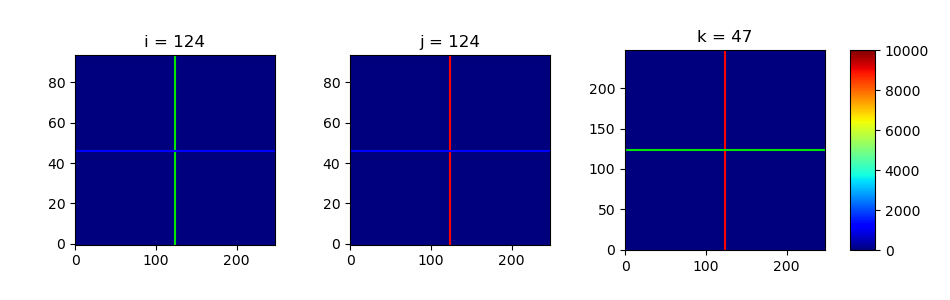

In [54]:
import project.visual.matplotlib as mpl_viz

nifti = project.core.fileio.load_nibabel(raster_base / 'E_pred.nii.gz')
array = nifti.get_fdata()

mpl_viz.SliceViewer(array, vox_spacing=spacing, cmap='jet', clim=(0, 1e4))

In [59]:
import project.visual.pyvista as pv_viz

mesh = project.core.fileio.load_meshio(output_path)

pv_viz.plot_mesh(mesh, scalars='E_pred', cmap='jet', clim=(0, 1e4)).show()

Loading outputs/optimize/case1/meshes/optimized.xdmf


TypeError: pyvista.plotting.plotter.BasePlotter.add_mesh() got multiple values for keyword argument 'show_scalar_bar'

# DEPRECATED

<IPython.core.display.Javascript object>


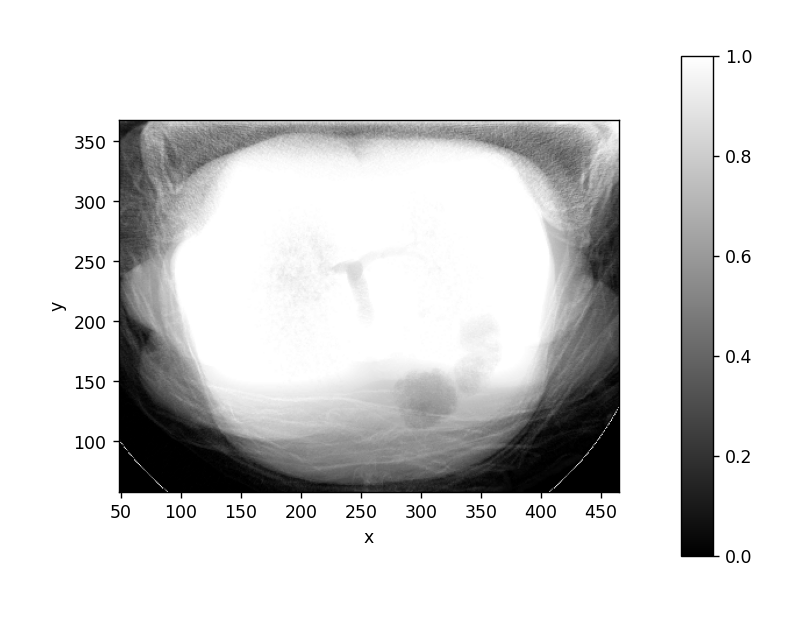

interactive(children=(Output(),), _dom_classes=('widget-interact',))

<IPython.core.display.Javascript object>


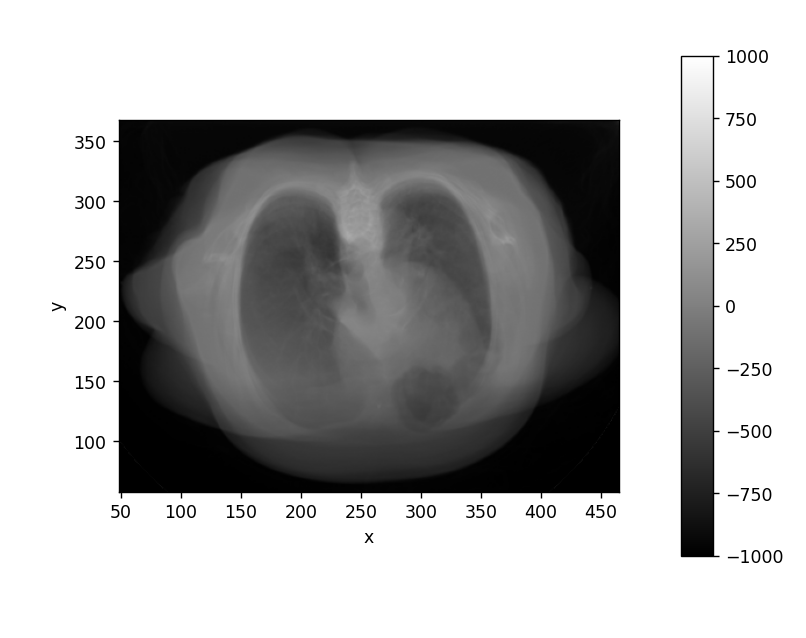

interactive(children=(Output(),), _dom_classes=('widget-interact',))

In [25]:
# manually annotate xy crops for each case
crops = [
    {'y': slice(20, 230)},
    {'y': slice( 0, 240)},
    {'y': slice(15, 245)},
    {'y': slice( 0, 255)},
    {'y': slice(10, 270)},
    
    {'x': slice(50, 500), 'y': slice(50, 380)},
    {'x': slice(50, 480), 'y': slice(80, 390)},
    {'x': slice(40, 450), 'y': slice(40, 350)},
    {'x': slice(50, 470), 'y': slice(90, 380)},
    {'x': slice(50, 480), 'y': slice(60, 380)},
]

i = 9
case = emory4dct[i]
anat = case.anat.sel(phase=0).mean('z')
mask = (case.anat.sel(phase=0) > -950).mean('z')

project.visual.view(mask[crops[i]], x='x', y='y', vmin=0, vmax=1)
project.visual.view(anat[crops[i]], x='x', y='y')

1.2795698924731183


<IPython.core.display.Javascript object>


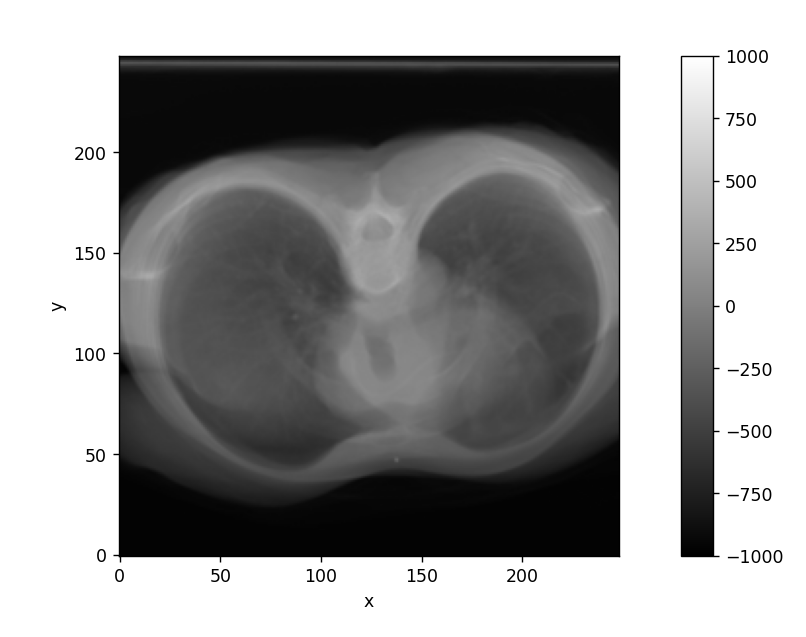

interactive(children=(Output(),), _dom_classes=('widget-interact',))

<IPython.core.display.Javascript object>


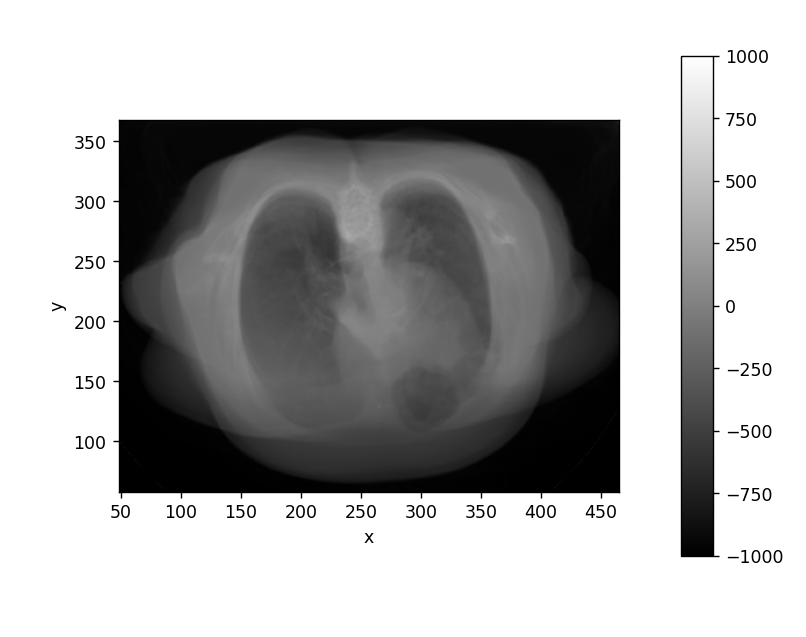

interactive(children=(Output(),), _dom_classes=('widget-interact',))

In [79]:
# register a single image pair

i = 9
case_fix = emory4dct[0]
case_mov = emory4dct[i]

anat_fix = case_fix.anat.sel(phase=0)
anat_mov = case_mov.anat.sel(phase=0)[crops[i]]

z_extent_fix = (anat_fix.z[-1] - anat_fix.z[0]).values
z_extent_mov = (anat_mov.z[-1] - anat_mov.z[0]).values
scale_init = z_extent_mov / z_extent_fix
print(scale_init)

project.visual.view(anat_fix.mean('z'), x='x', y='y')
project.visual.view(anat_mov.mean('z'), x='x', y='y')

In [80]:
%autoreload

transform = project.register.register_array(
    anat_mov,
    anat_fix,
    transform='similarity',
    center='geometry',
    metric='MI',
    scale_init=scale_init,
    num_scale_steps=0,
    learning_rate=1.0,
    num_iterations=0,
    print_every=1
)
scale_pred = transform.GetScale()
#scale_final = (scale_init + scale_pred) / 2
#transform.SetScale(scale_final)

warped = project.register.transform_array(
    anat_mov, anat_fix, transform, default=-1000
)

Start exhaustive search...
(0.0, 0.0, 0.0, 132.88999999999976, 89.24000000000093, 32.5, 1.2795698924731183) metric = -0.1621
Start iterative refinement...


<IPython.core.display.Javascript object>


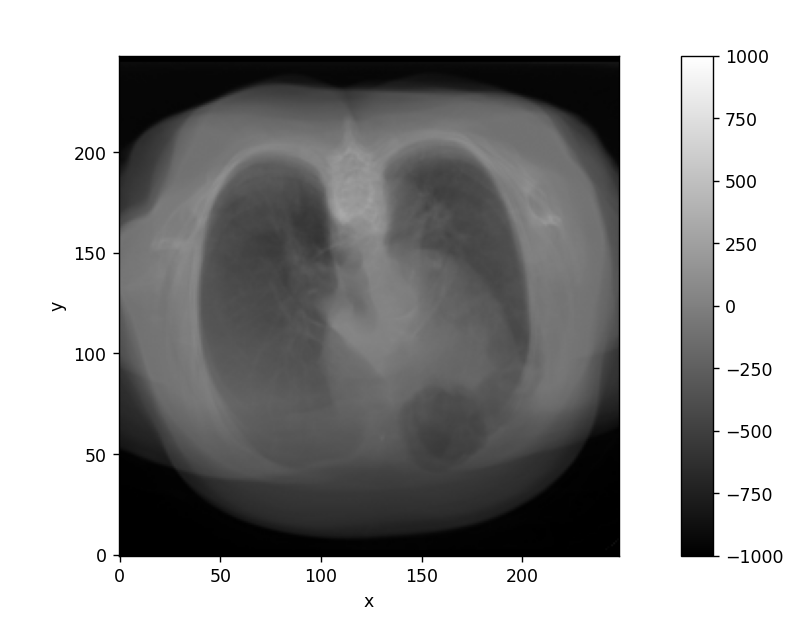

interactive(children=(Output(),), _dom_classes=('widget-interact',))

<IPython.core.display.Javascript object>


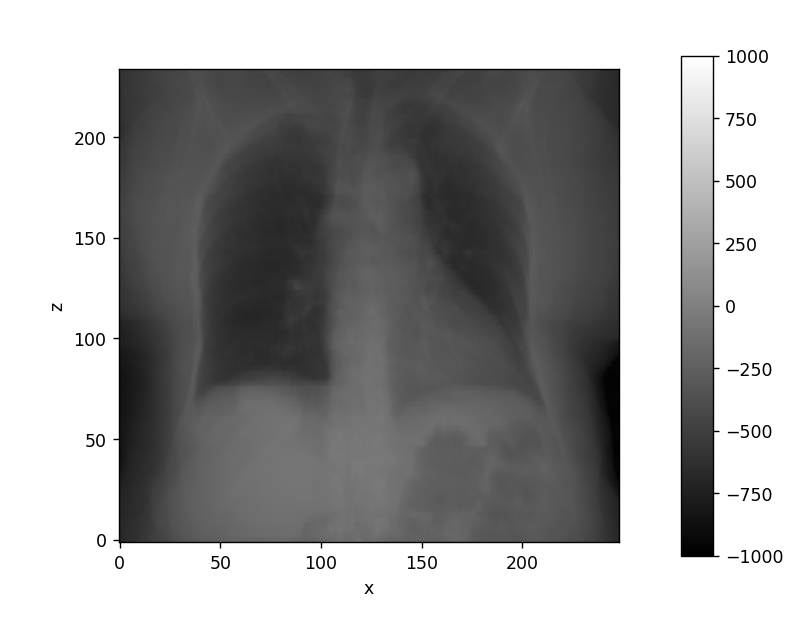

interactive(children=(Output(),), _dom_classes=('widget-interact',))

In [81]:
project.visual.view(warped.mean('z'), x='x', y='y')
project.visual.view(warped.mean('y'), x='x', y='z')

In [83]:
%%time

# register all cases to case 1 at EI phase

transforms = []
for i in range(len(emory4dct)):

    case_fix = emory4dct[0]
    case_mov = emory4dct[i]

    print(f'Registering {case_mov.case_name} to {case_fix.case_name}')

    # get transformation by registering at EI phase
    anat_fix = case_fix.anat.sel(phase=0)
    anat_mov = case_mov.anat.sel(phase=0)[crops[i]]
    
    z_extent_fix = (anat_fix.z[-1] - anat_fix.z[0]).values
    z_extent_mov = (anat_mov.z[-1] - anat_mov.z[0]).values
    scale_init = z_extent_mov / z_extent_fix
    
    transform = project.register.register_array(
        anat_mov,
        anat_fix,
        transform='similarity',
        center='geometry',
        metric='MI',
        scale_init=scale_init,
        num_scale_steps=0,
        num_iterations=0,
    )
    transforms.append(transform)

    # apply same transformation to all phases
    all_warped = []
    for phase in emory4dct.phases:
        print(f'Transforming {case_mov.case_name} phase {phase}')
        
        anat_fix = case_fix.anat.sel(phase=phase)
        anat_mov = case_mov.anat.sel(phase=phase)
        anat_warp = project.register.transform_array(anat_mov, anat_fix, transform, default=-1000)
        all_warped.append(anat_warp)
    
    # REPLACE existing image with warped image
    case_mov.anat = xr.concat(all_warped, dim=case_mov.anat.phase)
    case_mov.anat.name = 'CT'

    scale = transform.GetScale()
    case_mov.shape = case_fix.shape
    case_mov.resolution = [r * scale for r in case_fix.resolution]

Registering Case1Pack to Case1Pack
Start exhaustive search...
(0.0, 0.0, 0.0, 0.0, -2.909999999999755, 0.0, 1.0) metric = -0.5089
Start iterative refinement...
Transforming Case1Pack phase 0
Transforming Case1Pack phase 10
Transforming Case1Pack phase 20
Transforming Case1Pack phase 30
Transforming Case1Pack phase 40
Transforming Case1Pack phase 50
Transforming Case1Pack phase 60
Transforming Case1Pack phase 70
Transforming Case1Pack phase 80
Transforming Case1Pack phase 90
Registering Case2Pack to Case1Pack
Start exhaustive search...
(0.0, 0.0, 0.0, 24.22499999999998, 14.945000000000007, 22.5, 1.1935483870967742) metric = -0.2103
Start iterative refinement...
Transforming Case2Pack phase 0
Transforming Case2Pack phase 10
Transforming Case2Pack phase 20
Transforming Case2Pack phase 30
Transforming Case2Pack phase 40
Transforming Case2Pack phase 50
Transforming Case2Pack phase 60
Transforming Case2Pack phase 70
Transforming Case2Pack phase 80
Transforming Case2Pack phase 90
Registering 

In [84]:
all_anat = xr.DataArray(
    np.stack([case.anat.values for case in emory4dct.cases], axis=0),
    dims=['case', 'phase', 'x', 'y', 'z'],
    coords={
        'case': emory4dct.case_names,
        'phase': emory4dct.phases,
        'x': emory4dct[0].anat.x.values,
        'y': emory4dct[0].anat.y.values,
        'z': emory4dct[0].anat.z.values,
    }
)
all_anat

<xarray.DataArray (case: 10, phase: 10, x: 256, y: 256, z: 94)> Size: 1GB
array([[[[[-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          ...,
          [ -626,  -632,  -680, ...,  -716,  -664,  -796],
          [ -545,  -551,  -562, ...,  -388,  -458,  -494],
          [ -399,  -405,  -384, ...,  -381,  -347,  -422]],

         [[-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          ...,
          [ -616,  -624,  -670, ...,  -724,  -672,  -809],
          [ -548,  -533,  -547, ...,  -380,  -452,  -499],
          [ -402,  -398,  -367, ...,  -375,  -353,  -414]],

         [[-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          ...,
...
          ...,
          [ -843,  -834,  -797, ...,  -668,  -490,  -213],
          [ -693,  -686,  -687, ...,  -491,  -390,  -477],
          [ -436,  -455,  -416, ...,  -724,  -725,  -701]],

         [[ -999,  -999,  -999, ...,  -999,  -999,  -999],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [ -999,  -999,  -999, ...,  -999,  -999,  -999],
          ...,
          [ -831,  -818,  -856, ...,  -663,  -521,  -192],
          [ -707,  -707,  -655, ...,  -509,  -420,  -490],
          [ -499,  -428,  -448, ...,  -723,  -749,  -682]],

         [[-1000, -1000, -1000, ..., -1000, -1000, -1000],
          [ -999,  -999,  -999, ...,  -999,  -999,  -999],
          [-1000, -1000, -1000, ..., -1000, -1000, -1000],
          ...,
          [ -864,  -857,  -868, ...,  -657,  -516,  -186],
          [ -640,  -661,  -667, ...,  -532,  -432,  -500],
          [ -462,  -492,  -433, ...,  -729,  -756,  -695]]]]], dtype=int16)
Coordinates:
  * case     (case) <U11 440B 'Case1Pack' 'Case2Pack' ... 'Case10Pack'
  * phase    (phase) int64 80B 0 10 20 30 40 50 60 70 80 90
  * x        (x) float64 2kB 0.0 0.97 1.94 2.91 3.88 ... 244.4 245.4 246.4 247.3
  * y        (y) float64 2kB 0.0 0.97 1.94 2.91 3.88 ... 244.4 245.4 246.4 247.3
  * z        (z) float64 752B 0.0 2.5 5.0 7.5 10.0 ... 225.0 227.5 230.0 232.5

<IPython.core.display.Javascript object>


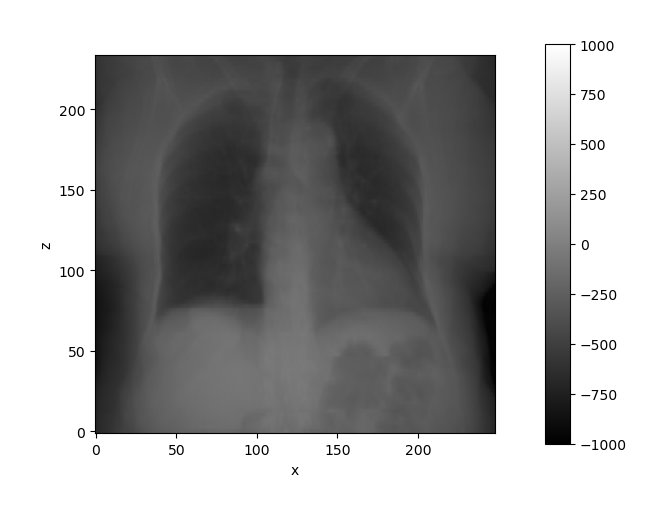

interactive(children=(SelectionSlider(description='case', options=(('Case1Pack', 0), ('Case2Pack', 1), ('Case3…

In [88]:
all_anat.name = 'CT'
project.visual.view(all_anat.mean('y'), x='x', y='z')

In [87]:
# save warped images as NIFTI files
emory4dct.save_niftis()

Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T00.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T10.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T20.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T30.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T40.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T50.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T60.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T70.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T80.nii.gz
Saving ../data/Emory-4DCT/Case1Pack/NIFTI/case1_T90.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T00.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T10.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T20.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T30.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T40.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T50.nii.gz
Saving ../data/Emory-4DCT/Case2Pack/NIFTI/case2_T60.nii.